In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder 
# for shape histogram
import seaborn as sns 
sns.set()
np.set_printoptions(suppress=True)

In [2]:
#Read a comma-separated values (csv) file into DataFrame.
data=pd.read_csv('weatherHistory.csv')
#.head():n Returns the first row
data.head(5)

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [3]:
#Read a comma-separated values (csv) file into DataFrame.
dataset=data.drop(['Formatted Date', 'Summary','Precip Type','Daily Summary','Loud Cover'], axis=1)
#.head():n Returns the first row
dataset.head()


,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars)
0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,1015.13
1,9.355556,7.227778,0.86,14.2646,259.0,15.8263,1015.63
2,9.377778,9.377778,0.89,3.9284,204.0,14.9569,1015.94
3,8.288889,5.944444,0.83,14.1036,269.0,15.8263,1016.41
4,8.755556,6.977778,0.83,11.0446,259.0,15.8263,1016.51


In [4]:
#Convert dataset table to array
arr=np.array(dataset)
arr

array([[   9.47222222,    7.38888889,    0.89      , ...,  251.        ,
          15.8263    , 1015.13      ],
       [   9.35555556,    7.22777778,    0.86      , ...,  259.        ,
          15.8263    , 1015.63      ],
       [   9.37777778,    9.37777778,    0.89      , ...,  204.        ,
          14.9569    , 1015.94      ],
       ...,
       [  22.03888889,   22.03888889,    0.56      , ...,   30.        ,
          16.1       , 1015.66      ],
       [  21.52222222,   21.52222222,    0.6       , ...,   20.        ,
          16.1       , 1015.95      ],
       [  20.43888889,   20.43888889,    0.61      , ...,   39.        ,
          15.5204    , 1016.16      ]])

In [5]:
y=arr[:,0]
y

array([ 9.47222222,  9.35555556,  9.37777778, ..., 22.03888889,
       21.52222222, 20.43888889])

In [6]:
X=arr[:,1:]
X

array([[   7.38888889,    0.89      ,   14.1197    ,  251.        ,
          15.8263    , 1015.13      ],
       [   7.22777778,    0.86      ,   14.2646    ,  259.        ,
          15.8263    , 1015.63      ],
       [   9.37777778,    0.89      ,    3.9284    ,  204.        ,
          14.9569    , 1015.94      ],
       ...,
       [  22.03888889,    0.56      ,    8.9838    ,   30.        ,
          16.1       , 1015.66      ],
       [  21.52222222,    0.6       ,   10.5294    ,   20.        ,
          16.1       , 1015.95      ],
       [  20.43888889,    0.61      ,    5.8765    ,   39.        ,
          15.5204    , 1016.16      ]])

In [7]:
dataset.shape

(96453, 7)

In [7]:
#train 0.8 data from X
X_train = X[:round(.8* len(X)) ]
#test : From 0.8 onwards X for test=0.2
X_test = X[round(.8 * len(X)):]
#train 0.8 data from y
y_train = y[:round(.8* len(y)) ]
#test : From 0.8 onwards y for test=0.2
y_test = y[round(.8 * len(y)):]

normalized_data_X_train

In [8]:
# Step 1: Calculate the mean and standard deviation for each feature
mean = np.mean(X_train, axis=0)
std_dev = np.std(X_train, axis=0)

# Step 2: Apply z-score standardization
normalized_data_X_train = (X_train - mean) / std_dev

# Now, 'normalized_data_X_train' contains the normalized values.

print("Original Data:")
print(X_train)
print("\nNormalized Data:")
print(normalized_data_X_train)


Original Data:
[[   7.38888889    0.89         14.1197      251.           15.8263
  1015.13      ]
 [   7.22777778    0.86         14.2646      259.           15.8263
  1015.63      ]
 [   9.37777778    0.89          3.9284      204.           14.9569
  1015.94      ]
 ...
 [   1.16111111    0.92          3.2039      339.            1.932
  1026.63      ]
 [  -0.11111111    0.93          3.059         7.            2.7853
  1026.62      ]
 [  -0.94444444    0.93          3.22          0.            0.2737
  1026.51      ]]

Normalized Data:
[[-0.30919471  0.81132919  0.46433261  0.57937612  1.41018962  0.11128749]
 [-0.32405062  0.65872413  0.48503189  0.65370608  1.41018962  0.11531789]
 [-0.12580097  0.81132919 -0.99151667  0.1426876   1.19309847  0.11781674]
 ...
 [-0.88345275  0.96393425 -1.09501307  1.39700569 -2.05924844  0.20398671]
 [-1.00076327  1.0148026  -1.11571235 -1.6876877  -1.84617751  0.2039061 ]
 [-1.07760422  1.0148026  -1.09271315 -1.75272641 -2.47332969  0.2030194

normalized_data_X_test

In [9]:
# Step 1: Calculate the mean and standard deviation for each feature
mean = np.mean(X_test, axis=0)
std_dev = np.std(X_test, axis=0)

# Step 2: Apply z-score standardization
normalized_data_X_test = (X_test - mean) / std_dev

# Now, 'normalized_data_X_test' contains the normalized values.

print("Original Data:")
print(X_test)
print("\nNormalized Data:")
print(normalized_data_X_test)

Original Data:
[[   0.07222222    0.93          1.61        280.            0.2737
  1026.4       ]
 [   0.35555556    0.99          3.1073       52.            0.9177
  1026.46      ]
 [   1.13888889    1.            1.5295       70.            1.1592
  1026.5       ]
 ...
 [  22.03888889    0.56          8.9838       30.           16.1
  1015.66      ]
 [  21.52222222    0.6          10.5294       20.           16.1
  1015.95      ]
 [  20.43888889    0.61          5.8765       39.           15.5204
  1016.16      ]]

Normalized Data:
[[-1.11565775  0.93464163 -1.36887986  0.91295977 -2.23387218  0.18850432]
 [-1.08752118  1.25053739 -1.14028469 -1.23241597 -2.10001833  0.18923324]
 [-1.00973184  1.30318668 -1.38116993 -1.0630442  -2.04982314  0.18971919]
 ...
 [ 1.06575388 -1.01338222 -0.24311008 -1.43942591  1.05558621  0.05802703]
 [ 1.01444602 -0.80278505 -0.00714086 -1.53352133  1.05558621  0.06155016]
 [ 0.90686502 -0.75013575 -0.71750652 -1.35474002  0.93511774  0.06410139]]


In [49]:
# # Step 1: Calculate the mean and standard deviation for each feature
# mean = np.mean(y_train, axis=0)
# std_dev = np.std(y_train, axis=0)

# # Step 2: Apply z-score standardization
# normalized_data_y_train = (y_train - mean) / std_dev

# # Now, 'normalized_data' contains the normalized values.

# print("Original Data:")
# print(y_train)
# print("\nNormalized Data:")
# print(normalized_data_y_train)

In [50]:
# mean = np.mean(y_test, axis=0)
# std_dev = np.std(y_test, axis=0)

# # Step 2: Apply z-score standardization
# normalized_data_y_test = (y_test - mean) / std_dev

# # Now, 'normalized_data' contains the normalized values.

# print("Original Data:")
# print(y_test)
# print("\nNormalized Data:")
# print(normalized_data_y_test)

In [11]:
y_test.shape

(19291,)

In [12]:
normalized_data_X_train.shape[0]

77162

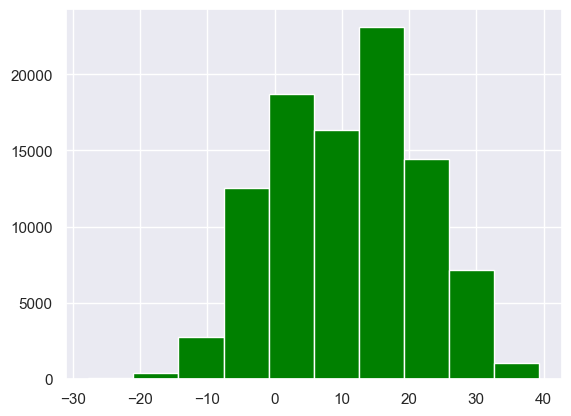

In [11]:
plt.hist(X[:,0],bins=10,color='green')
plt.show()

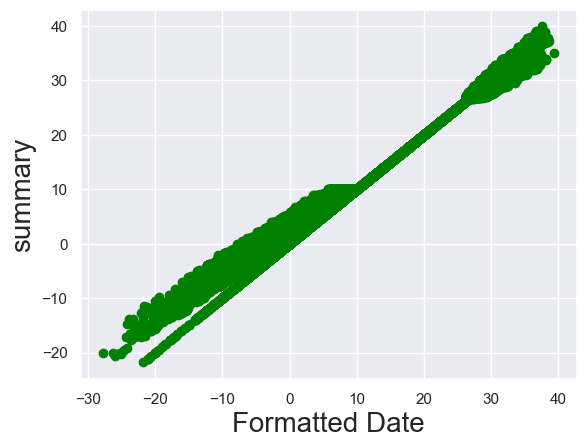

In [12]:
# for Apparent Temperature (C)
I=X[:,0]
plt.scatter(I,y,color='green')
plt.xlabel("Apparent Temperature (C)",fontsize=20)
plt.ylabel("Temperature (C)",fontsize=20)
plt.show()

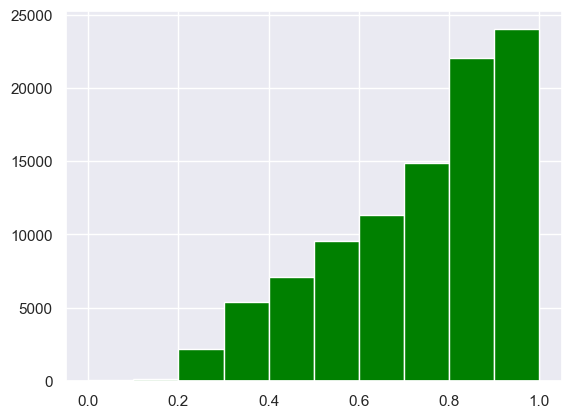

In [13]:
plt.hist(X[:,1],bins=10,color='green')
plt.show()

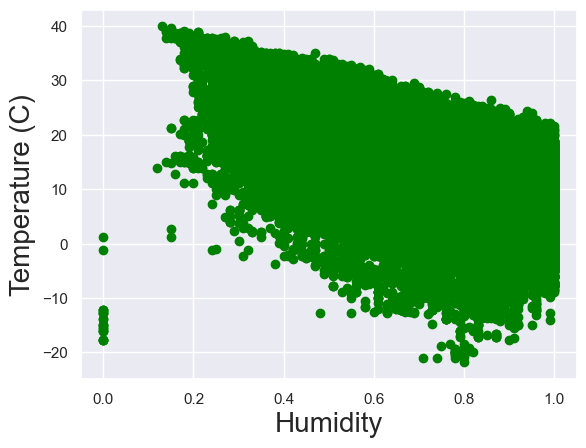

In [14]:
# for Humidity
I=X[:,1]
plt.scatter(I,y,color='green')
plt.xlabel("Humidity",fontsize=20)
plt.ylabel("Temperature (C)",fontsize=20)
plt.show()


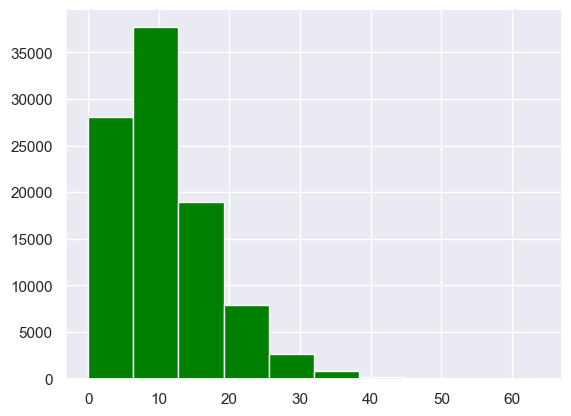

In [15]:
plt.hist(X[:,2],bins=10,color='green')
plt.show()

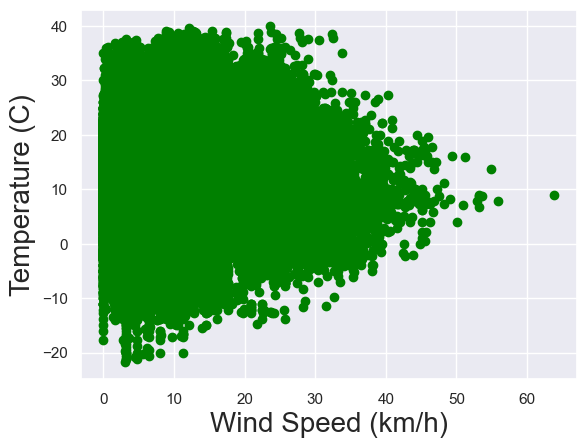

In [16]:
# for Wind Speed (km/h)
I=X[:,2]
plt.scatter(I,y,color='green')
plt.xlabel("Wind Speed (km/h)",fontsize=20)
plt.ylabel("Temperature (C)",fontsize=20)
plt.show()

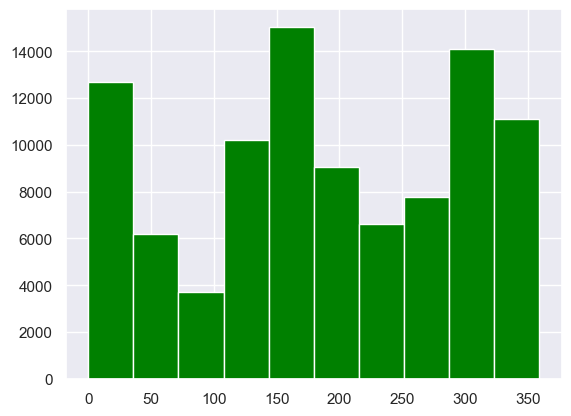

In [17]:
plt.hist(X[:,3],bins=10,color='green')
plt.show()

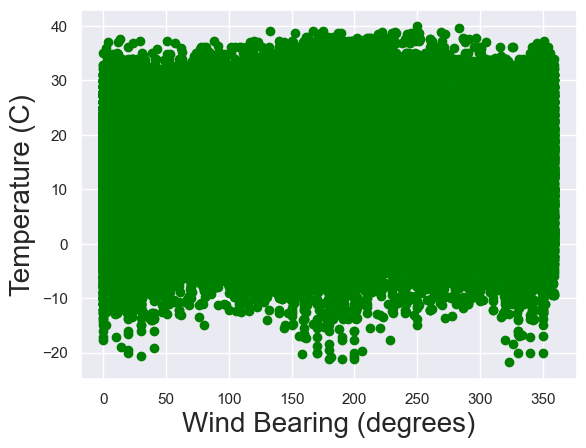

In [18]:
# for Wind Bearing (degrees)
I=X[:,3]
plt.scatter(I,y,color='green')
plt.xlabel("Wind Bearing (degrees)",fontsize=20)
plt.ylabel("Temperature (C)",fontsize=20)
plt.show()

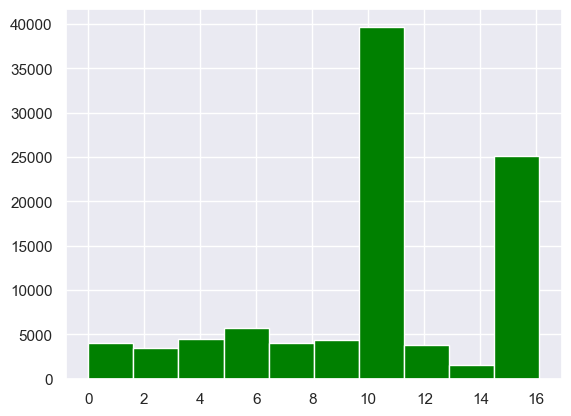

In [19]:
plt.hist(X[:,4],bins=10,color='green')
plt.show()

c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


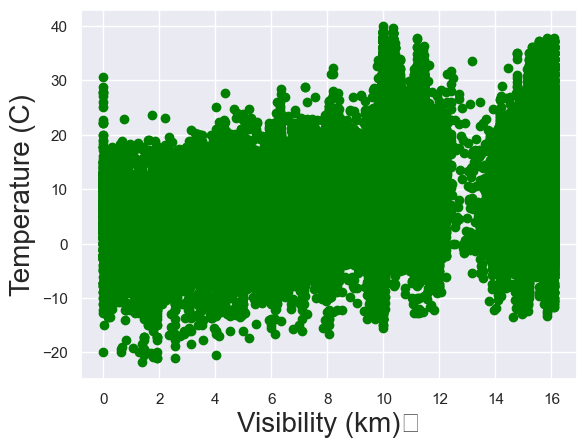

In [20]:
# for Visibility (km)
I=X[:,4]
plt.scatter(I,y,color='green')
plt.xlabel("Visibility (km)	",fontsize=20)
plt.ylabel("Temperature (C)",fontsize=20)
plt.show()

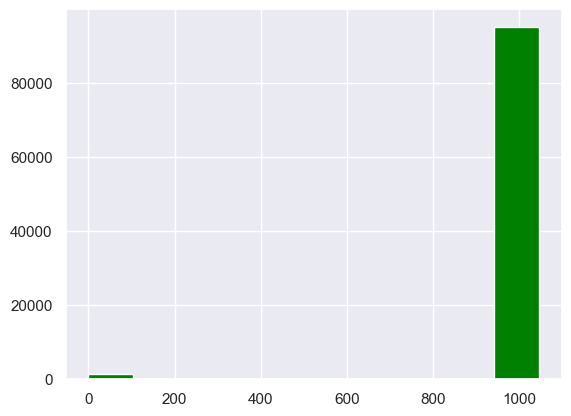

In [21]:
plt.hist(X[:,5],bins=10,color='green')
plt.show()

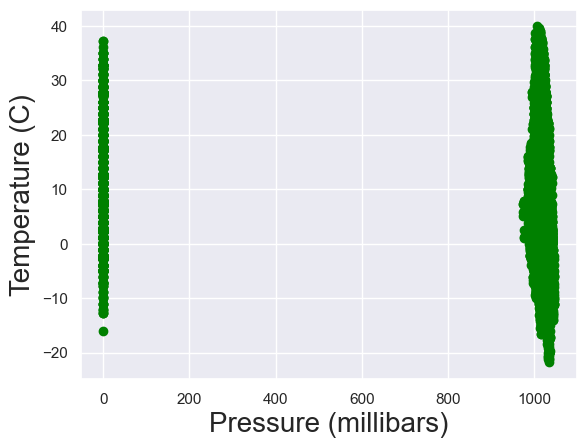

In [22]:
# for Pressure (millibars)
I=X[:,5]
plt.scatter(I,y,color='green')
plt.xlabel("Pressure (millibars)",fontsize=20)
plt.ylabel("Temperature (C)",fontsize=20)
plt.show()

2

In [ ]:


# X_new_test=np.hstack((np.ones((normalized_data_X_test.shape[0],1)),normalized_data_X_test))
# def predict(X,weights):
#     y_pred = np.dot(X,weights)
#     return y_pred

# #Make predictions on the test 
# y_pred = predict(X_new_test,weights)

# def r2_score(y,y_pred):
#     mean_y = sum(y)/len(y)
#     T_ss = sum((y-mean_y)**2)
#     R_ss = sum((y-y_pred)**2)
#     R2 = 1-R_ss/T_ss
#     return R2

# #Calculate R^2 score
# r2_score(y_test,y_pred)
# print(r2_score(y_test,y_pred))


In [13]:
from numpy.linalg import inv
import time
 # Add a column of ones for the bias term
X_new_train=np.hstack((np.ones((normalized_data_X_train.shape[0],1)),normalized_data_X_train))
X_new_test=np.hstack((np.ones((normalized_data_X_test.shape[0],1)),normalized_data_X_test))
#transpose X_new_train
X_new_T=np.transpose(X_new_train)
# Record the start time
start_time = time.time()
theta = []
# Calculate the linear regression solution using the normal equations
# theta=np.linalg.inv(X_new_T.dot(X_new)).dot(X_new_T).dot(y_new)

# Calculate parameters using the normal equation
theta_X=np.linalg.inv(X_new_T@(X_new_train))
theta_y=X_new_T@y_train
theta=theta_X@theta_y
theta

def predict(X,theta):
    y_pred = np.dot(X,theta)
    return y_pred

#Make predictions on the test 
y_pred = predict(X_new_test,theta)

def r2_score(y,y_pred):
    mean_y = sum(y)/len(y)
    T_ss = sum((y-mean_y)**2)
    R_ss = sum((y-y_pred)**2)
    R2 = 1-R_ss/T_ss
    return R2

#Calculate R^2 score
r2_score(y_test,y_pred)
print(r2_score(y_test,y_pred))

# Record the end time
end_time = time.time()

# Calculate the running time
running_time = end_time - start_time
print("\nRunning Time:", running_time, "seconds")
print(theta)



0.9816115936444372

Running Time: 0.014719724655151367 seconds
[11.83906665  9.46391074 -0.28539054  0.58429726 -0.04235497  0.03143913
 -0.02051252]


3

In [14]:
weights = np.zeros(normalized_data_X_train.shape[1])
weights

array([0., 0., 0., 0., 0., 0.])

In [21]:
n=normalized_data_X_train.shape[0]
d=normalized_data_X_train.shape[1]
print(n)
print(d)

77162
6


In [15]:
permutation = np.random.permutation(77162)
permutation
X_shuffled = X_new_train[permutation]
X_shuffled.shape
X_mini_batch = X_shuffled[0:0 + 10]
X_mini_batch

array([[ 1.        , -0.26667605,  0.45525072, -0.4395359 , -1.41824159,
         0.99610836,  0.10508067],
       [ 1.        ,  0.93665324, -0.66385303,  1.17730777,  1.39700569,
         0.04331947,  0.14030638],
       [ 1.        ,  0.78348361,  0.55698743, -1.55269712, -1.75272641,
         1.41018962,  0.12402356],
       [ 1.        , -0.32251381,  0.65872413, -1.5158984 ,  0.13339635,
        -1.51250038,  0.05905349],
       [ 1.        ,  0.53810484,  0.25177731, -1.09271315, -0.17321474,
         1.41018962,  0.10685405],
       [ 1.        , -1.0248401 ,  1.16740766, -0.78222397, -1.71556143,
        -2.09141009,  0.15618615],
       [ 1.        , -0.51461618,  1.16740766, -1.02371555, -0.49840832,
        -2.46126907,  0.0229411 ],
       [ 1.        , -1.48895944,  1.32001272, -0.33143967, -1.37178536,
        -1.95070287,  0.11523728],
       [ 1.        , -1.08989877,  0.20090896, -0.5430323 ,  1.36913196,
        -0.64413582,  0.22026953],
       [ 1.        ,  0.7348

In [16]:
permutation = np.random.permutation(10)
print(permutation)
X_shuffled=normalized_data_X_train[permutation]
print(X_shuffled)

[5 7 9 4 3 1 2 6 8 0]
[[-0.33480836  0.60785578  0.44133341  0.64441484  1.19309847  0.12362052]
 [-0.38859702  0.81132919  0.46893245  0.66299733 -0.04914528  0.12507146]
 [ 0.27940698 -0.0534328   0.23664054  0.83953099 -0.04914528  0.12813456]
 [-0.34710291  0.50611908  0.02504791  0.65370608  1.41018962  0.1224114 ]
 [-0.44238569  0.50611908  0.46203269  0.74661853  1.41018962  0.12160531]
 [-0.32405062  0.65872413  0.48503189  0.65370608  1.41018962  0.11531789]
 [-0.12580097  0.81132919 -0.99151667  0.1426876   1.19309847  0.11781674]
 [-0.48131844  1.11653931  0.21364134  0.65370608 -0.04914528  0.12410416]
 [ 0.00739001  0.45525072  0.06414655  0.65370608 -0.04914528  0.12934368]
 [-0.30919471  0.81132919  0.46433261  0.57937612  1.41018962  0.11128749]]


In [34]:
# permutation = np.random.permutation(n)
# permutation
# X_shuffled=normalized_data_X_train[permutation]
# X_mini_batch = X_shuffled[0:0 + 10]
# X_mini_batch

In [36]:
def mini_batch_sgd(X, y,learning_rate,batch_size, num_epochs):
    # Add a column of ones for the bias term
    X_new_train=np.hstack((np.ones((X.shape[0],1)),X))

    n=X_new_train.shape[0]
    d=X_new_train.shape[1]
    weights = np.zeros(d)  # Initialize weights with zeros=theta
 

    for epoch in range(num_epochs):
        # Shuffle the data at the beginning of each epoch to ensure randomness
        permutation = np.random.permutation(n)
        X_shuffled = X_new_train[permutation]
        y_shuffled = y[permutation]

        for i in range(0, n, batch_size):
            # Create a mini-batch from the shuffled data
            X_mini_batch = X_shuffled[i:i + batch_size]
            y_mini_batch = y_shuffled[i:i + batch_size]

            predictions = X_mini_batch.dot(weights)
            errors = predictions - y_mini_batch

            # Compute the gradient for the mini-batch
            X_mini_batch_T=np.transpose(X_mini_batch)
            gradient = (2/batch_size)* np.dot(X_mini_batch_T,errors)
            
            
            weights -= learning_rate * gradient
    
    return weights




In [19]:
weights = mini_batch_sgd(normalized_data_X_train,y_train,learning_rate=0.1, batch_size=10, num_epochs=100)

In [58]:
weights

array([11.88525366,  9.44370976, -0.27404017,  0.40294097,  0.01662958,
       -0.07911036, -0.00020899])

In [56]:
X_new_test=np.hstack((np.ones((normalized_data_X_test.shape[0],1)),normalized_data_X_test))
def predict(X,weights):
    y_pred = np.dot(X,weights)
    return y_pred

#Make predictions on the test 
y_pred = predict(X_new_test,weights)

def r2_score(y,y_pred):
    mean_y = sum(y)/len(y)
    T_ss = sum((y-mean_y)**2)
    R_ss = sum((y-y_pred)**2)
    R2 = 1-R_ss/T_ss
    return R2

#Calculate R^2 score
r2_score(y_test,y_pred)
print(r2_score(y_test,y_pred))

0.9808749514247046


In [59]:
weights = mini_batch_sgd(normalized_data_X_train,y_train,learning_rate=0.1, batch_size=20, num_epochs=100)

In [60]:
weights

array([11.9092688 ,  9.47616958, -0.15944688,  0.66449563, -0.02130242,
        0.02680543,  0.01478556])

In [61]:
X_new_test=np.hstack((np.ones((normalized_data_X_test.shape[0],1)),normalized_data_X_test))
def predict(X,weights):
    y_pred = np.dot(X,weights)
    return y_pred

#Make predictions on the test 
y_pred = predict(X_new_test,weights)

def r2_score(y,y_pred):
    mean_y = sum(y)/len(y)
    T_ss = sum((y-mean_y)**2)
    R_ss = sum((y-y_pred)**2)
    R2 = 1-R_ss/T_ss
    return R2

#Calculate R^2 score
r2_score(y_test,y_pred)
print(r2_score(y_test,y_pred))

0.9831221421739512


In [77]:
weights = mini_batch_sgd(normalized_data_X_train,y_train,learning_rate=0.1, batch_size=30, num_epochs=100)

In [78]:
weights

array([11.80606063,  9.44151456, -0.257857  ,  0.59559229,  0.04827888,
        0.02107234, -0.01336517])

In [79]:
X_new_test=np.hstack((np.ones((normalized_data_X_test.shape[0],1)),normalized_data_X_test))
def predict(X,weights):
    y_pred = np.dot(X,weights)
    return y_pred

#Make predictions on the test 
y_pred = predict(X_new_test,weights)

def r2_score(y,y_pred):
    mean_y = sum(y)/len(y)
    T_ss = sum((y-mean_y)**2)
    R_ss = sum((y-y_pred)**2)
    R2 = 1-R_ss/T_ss
    return R2

#Calculate R^2 score
r2_score(y_test,y_pred)
print(r2_score(y_test,y_pred))

0.9817343400626438


In [65]:
weights = mini_batch_sgd(normalized_data_X_train,y_train,learning_rate=0.1, batch_size=40, num_epochs=100)

In [66]:
weights

array([11.82631217,  9.44451171, -0.34004873,  0.49379265,  0.01551611,
        0.04228844, -0.01886932])

In [67]:
X_new_test=np.hstack((np.ones((normalized_data_X_test.shape[0],1)),normalized_data_X_test))
def predict(X,weights):
    y_pred = np.dot(X,weights)
    return y_pred

#Make predictions on the test 
y_pred = predict(X_new_test,weights)

def r2_score(y,y_pred):
    mean_y = sum(y)/len(y)
    T_ss = sum((y-mean_y)**2)
    R_ss = sum((y-y_pred)**2)
    R2 = 1-R_ss/T_ss
    return R2

#Calculate R^2 score
r2_score(y_test,y_pred)
print(r2_score(y_test,y_pred))

0.9811839211346159


In [68]:
weights = mini_batch_sgd(normalized_data_X_train,y_train,learning_rate=0.1, batch_size=50, num_epochs=100)

In [69]:
weights

array([11.88981135,  9.46434052, -0.27373258,  0.63466057, -0.01512715,
        0.06850629, -0.01296892])

In [70]:
X_new_test=np.hstack((np.ones((normalized_data_X_test.shape[0],1)),normalized_data_X_test))
def predict(X,weights):
    y_pred = np.dot(X,weights)
    return y_pred

#Make predictions on the test 
y_pred = predict(X_new_test,weights)

def r2_score(y,y_pred):
    mean_y = sum(y)/len(y)
    T_ss = sum((y-mean_y)**2)
    R_ss = sum((y-y_pred)**2)
    R2 = 1-R_ss/T_ss
    return R2

#Calculate R^2 score
r2_score(y_test,y_pred)
print(r2_score(y_test,y_pred))

0.9817093164938259


In [71]:
weights = mini_batch_sgd(normalized_data_X_train,y_train,learning_rate=0.1, batch_size=100, num_epochs=100)

In [72]:
weights

array([11.8279307 ,  9.46828202, -0.26973651,  0.59032811, -0.00482127,
        0.02709067, -0.00842187])

In [73]:
X_new_test=np.hstack((np.ones((normalized_data_X_test.shape[0],1)),normalized_data_X_test))
def predict(X,weights):
    y_pred = np.dot(X,weights)
    return y_pred

#Make predictions on the test 
y_pred = predict(X_new_test,weights)

def r2_score(y,y_pred):
    mean_y = sum(y)/len(y)
    T_ss = sum((y-mean_y)**2)
    R_ss = sum((y-y_pred)**2)
    R2 = 1-R_ss/T_ss
    return R2

#Calculate R^2 score
r2_score(y_test,y_pred)
print(r2_score(y_test,y_pred))

0.9815312114428538


4

In [19]:
X_new_train=np.hstack((np.ones((X.shape[0],1)),X))
X_b = np.c_[X_new_train, X_new_train**2]
X_b
X_b.shape

(96453, 14)

In [26]:
X_new_train=np.hstack((np.ones((normalized_data_X_train.shape[0],1)),normalized_data_X_train))

def add_polynomial_features(X):
   return np.c_[X, X**2]

X_poly = add_polynomial_features(X_new_train)
print(X_poly.shape)

(77162, 14)


In [31]:
def mini_batch_sgd(X, y,learning_rate,batch_size, num_epochs):
    # Add a column of ones for the bias term
    X_new_train=np.hstack((np.ones((X.shape[0],1)),X))
    d=2
   
    X_poly = np.column_stack([X_new_train**(i+1) for i in range(1, d + 1)])
  
    weights = np.ones(X_poly.shape[1])  # Initialize weights with zeros=theta
 

    for epoch in range(num_epochs):
        # Shuffle the data at the beginning of each epoch to ensure randomness
        # permutation = np.random.permutation(X_poly1.shape[0])
        # X_shuffled = X_poly[permutation]
        # y_shuffled = y[permutation]

        for i in range(0, X_poly.shape[0], batch_size):
            # Create a mini-batch from the shuffled data
            X_mini_batch = X_poly[i:i + batch_size]
            y_mini_batch = y[i:i + batch_size]

            predictions = X_mini_batch.dot(weights)
            errors = predictions - y_mini_batch

            # Compute the gradient for the mini-batch
            X_mini_batch_T=np.transpose(X_mini_batch)
            # print(X_mini_batch_T)
            gradient =(2/batch_size)*np.dot(X_mini_batch_T,errors)
            # print(gradient)
            
            weights -= learning_rate * gradient
    return weights

In [32]:
mini_batch_sgd(normalized_data_X_train, y_train,learning_rate=0.01,batch_size=10, num_epochs=100)

C:\Users\acer\AppData\Local\Temp\ipykernel_11596\930883649.py:42: RuntimeWarning: invalid value encountered in subtract
  weights -= learning_rate * gradient


array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan])

In [ ]:
mini_batch_sgd(normalized_data_X_train, y_train,learning_rate=0.01,batch_size=20, num_epochs=100)

In [ ]:
mini_batch_sgd(normalized_data_X_train, y_train,learning_rate=0.01,batch_size=30, num_epochs=100)

In [ ]:
mini_batch_sgd(normalized_data_X_train, y_train,learning_rate=0.01,batch_size=40, num_epochs=100)

In [ ]:
mini_batch_sgd(normalized_data_X_train, y_train,learning_rate=0.01,batch_size=50, num_epochs=100)

In [ ]:
mini_batch_sgd(normalized_data_X_train, y_train,learning_rate=0.01,batch_size=100, num_epochs=100)

5

In [41]:
def generate_polynomial_features(X, M):
    X_poly = np.column_stack([X**i for i in range(1, M + 1)])
    return X_poly
# X_poly = generate_polynomial_features(normalized_data_X_train, M)
# X_poly

In [21]:
X_new_train=np.hstack((np.ones((normalized_data_X_train.shape[0],1)),normalized_data_X_train))
    # X_poly = generate_polynomial_features(X_new_train, M)
X_poly = np.column_stack([X_new_train**(i+1) for i in range(1, 3)])
X_poly

array([[  1.        ,   0.09560137,   0.65825506, ...,   0.19448306,
          2.80435208,   0.00137828],
       [  1.        ,   0.10500881,   0.43391748, ...,   0.27934929,
          2.80435208,   0.00153352],
       [  1.        ,   0.01582588,   0.65825506, ...,   0.00290508,
          1.69835655,   0.00163539],
       ...,
       [  1.        ,   0.78048876,   0.92916924, ...,   2.72643111,
         -8.73225154,   0.008488  ],
       [  1.        ,   1.00152711,   1.02982432, ...,  -4.80702359,
         -6.29245858,   0.00847795],
       [  1.        ,   1.16123085,   1.02982432, ...,  -5.38446297,
        -15.13024754,   0.00836783]])

In [22]:
X_poly.shape

(77162, 14)

In [23]:
X_poly_T=np.transpose(X_poly)
X_poly_T

array([[  1.        ,   1.        ,   1.        , ...,   1.        ,
          1.        ,   1.        ],
       [  0.09560137,   0.10500881,   0.01582588, ...,   0.78048876,
          1.00152711,   1.16123085],
       [  0.65825506,   0.43391748,   0.65825506, ...,   0.92916924,
          1.02982432,   1.02982432],
       ...,
       [  0.19448306,   0.27934929,   0.00290508, ...,   2.72643111,
         -4.80702359,  -5.38446297],
       [  2.80435208,   2.80435208,   1.69835655, ...,  -8.73225154,
         -6.29245858, -15.13024754],
       [  0.00137828,   0.00153352,   0.00163539, ...,   0.008488  ,
          0.00847795,   0.00836783]])

In [24]:
weights = np.linalg.inv(X_poly_T.dot(X_poly))
weights

array([[ 4.54352044e+21,  7.31795264e+07, -1.38086645e+08,
         1.89871125e+07,  1.37568208e+08,  4.02880203e+07,
        -6.87530347e+10, -4.54352044e+21, -1.34231760e+08,
        -8.66620411e+07, -2.34315781e+07, -1.06511543e+07,
        -5.84221446e+07, -8.51528987e+09],
       [-3.62280355e+06,  1.32749569e-05, -8.67042422e-07,
         9.69727030e-07,  1.80394454e-07,  3.76149112e-07,
         1.45144826e-06,  3.62280355e+06,  1.69130340e-06,
         2.11808746e-06, -1.72068170e-07,  9.56422022e-08,
         8.72727028e-07,  1.78536511e-07],
       [ 6.76598096e+06, -8.68171393e-07,  3.86391714e-05,
         9.90849335e-08, -8.66739068e-07, -2.54715725e-06,
        -2.85719116e-06, -6.76598096e+06, -1.89728684e-06,
         1.31025684e-05,  9.12796471e-08, -2.28946101e-07,
         3.64239572e-06, -3.68205814e-07],
       [-8.98563519e+05,  9.70393941e-07,  9.81194223e-08,
         1.82168490e-05, -1.33700631e-06, -1.54135834e-07,
         3.49555677e-08,  8.98563519e+05,  1.

In [76]:
def polynomial_regression(X, y, M):
    X_new_train=np.hstack((np.ones((X.shape[0],1)),X))
    # print('X_new_train=',X_new_train)
    #  print(X_new_train.shape)
    # X_poly = generate_polynomial_features(X_new_train, M)
    X_poly = np.column_stack([X_new_train**(i+1) for i in range(1, M + 1)])
    # print(X_poly.shape)
    # print(X_poly)
    # Perform linear regression on the polynomial features
    X_poly_T=np.transpose(X_poly)
    # print(X_poly_T)
    weights = np.linalg.inv(X_poly_T.dot(X_poly)).dot(X_poly_T).dot(y)
   
    # print(X_poly_T.dot(X_poly))
    # a=X_poly_T.dot(X_poly)
    # print(a.shape)
    #Method2:
    # weight0=np.linalg.inv(X_poly_T@(X_poly))
    # weight1=weight0@X_poly_T
    # weight2=weight1@y
    return weights

In [77]:
weights=polynomial_regression(normalized_data_X_train,y_train, 2)
weights

array([ 1.25000051e+14,  5.71277833e+01, -1.54764983e+00,  3.84936238e+00,
        1.38293751e+01,  3.75695331e-01,  4.25411935e-01, -1.24042150e+14,
        2.49413688e+00, -5.36766835e-01,  3.01240894e-02,  3.46835833e-02,
        3.39543591e-01,  1.41268051e-02])

6

In [37]:
# Add a bias term to the features
# X_bias = np.c_[np.ones((normalized_data_X_train.shape[0], 1)), normalized_data_X_train]
# X_bias

array([[ 1.        , -0.30919471,  0.81132919, ...,  0.57937612,
         1.41018962,  0.11128749],
       [ 1.        , -0.32405062,  0.65872413, ...,  0.65370608,
         1.41018962,  0.11531789],
       [ 1.        , -0.12580097,  0.81132919, ...,  0.1426876 ,
         1.19309847,  0.11781674],
       ...,
       [ 1.        , -0.88345275,  0.96393425, ...,  1.39700569,
        -2.05924844,  0.20398671],
       [ 1.        , -1.00076327,  1.0148026 , ..., -1.6876877 ,
        -1.84617751,  0.2039061 ],
       [ 1.        , -1.07760422,  1.0148026 , ..., -1.75272641,
        -2.47332969,  0.20301941]])

In [38]:
# Initialize parameters
# theta = np.random.randn(X_bias.shape[1])
# theta

array([-0.82718948,  0.47816731, -0.44943497,  1.19573418, -0.95785028,
       -0.12076389, -0.30084193])

In [39]:
# Hyperparameters
# learning_rate = 0.1
# epsilon = 1e-8  # Small constant to avoid division by zero in AdaGrad
# num_iterations = 100

In [40]:
# Initialize the squared gradient accumulator
# grad_squared = np.zeros_like(theta)
# grad_squared

array([0., 0., 0., 0., 0., 0., 0.])

In [32]:
# AdaGrad optimization
# for iteration in range(num_iterations):
#     # Calculate the predicted values
#     y_pred = X_bias.dot(theta) 

#     # Calculate the errors
#     errors = y_pred - y_train
    
#     # Calculate the gradients
#     X_bias_T=np.transpose(X_bias)
#     gradients = X_bias_T.dot(errors)/ len(y_train)

#     # Update the squared gradient accumulator
#     grad_squared += gradients**2

#     # Update the parameters using AdaGrad update rule
#     theta -= (learning_rate / (np.sqrt(grad_squared) + epsilon)) * gradients

# # Print the final parameters
# print("Final Parameters (theta):", theta)

In [85]:
# X_bias = np.c_[np.ones((normalized_data_X_train.shape[0], 1)), normalized_data_X_train]
# X_bias

# # Initialize parameters
# theta = np.random.randn(X_bias.shape[1])
# theta

# # Hyperparameters
# learning_rate = 0.1
# epsilon = 1e-8  # Small constant to avoid division by zero in AdaGrad
# num_iterations = 100

# # Initialize the squared gradient accumulator
# grad_squared = np.zeros_like(theta)
# grad_squared

# n=X_bias.shape[0]

# batch_size=30

# AdaGrad optimization
def AdaGrad(X,y,num_iterations):
    # Hyperparameters
    X_new_train = np.c_[np.ones((X.shape[0], 1)), X]
    learning_rate = 0.1
    epsilon = 1e-8  # Small constant to avoid division by zero in AdaGrad
    num_iterations = 100
    theta = np.random.randn(X_new_train.shape[1])
    # print(theta)
    # theta
    
    # X_new_train = np.c_[np.ones((X.shape[0], 1)), X]
    n=X_new_train.shape[0]
    batch_size=30
    grad_squared = np.zeros_like(theta)
    # print(grad_squared)
    # grad_squared
    for iteration in range(num_iterations):
        for i in range(0, n, batch_size):
                # Create a mini-batch 
                X_batch =  X_new_train[i:i + batch_size]
                y_batch = y[i:i + batch_size]
                X_batch_T=np.transpose(X_batch)
                gradients = 2 / len(X_batch) * X_batch_T.dot(X_batch.dot(theta) - y_batch)
                # Update the squared gradient accumulator
                grad_squared += gradients**2
                # Update the parameters using AdaGrad update rule
                theta -= (learning_rate / (np.sqrt(grad_squared) + epsilon)) * gradients
    return theta



In [86]:
theta=AdaGrad(normalized_data_X_train,y_train,num_iterations=100)
theta

array([11.83710478,  9.46296938, -0.28346829,  0.58137093, -0.04663408,
        0.03184992, -0.02558887])

In [35]:
X_new_test=np.hstack((np.ones((normalized_data_X_test.shape[0],1)),normalized_data_X_test))
def predict(X,theta):
    y_pred = np.dot(X,theta)
    return y_pred

#Make predictions on the test 
y_pred = predict(X_new_test,theta)

def r2_score(y,y_pred):
    mean_y = sum(y)/len(y)
    T_ss = sum((y-mean_y)**2)
    R_ss = sum((y-y_pred)**2)
    R2 = 1-R_ss/T_ss
    return R2

#Calculate R^2 score
r2_score(y_test,y_pred)
print(r2_score(y_test,y_pred))

0.9816403165559708


7

In [24]:
# def linear_regression_sgd_momentum(X, y, learning_rate=0.01, momentum_factor=0.9, num_epochs=100):
#     # Add a bias term to the features
#     X_bias = np.c_[np.ones((X.shape[0], 1)), X]

#     # Initialize parameters
#     theta = np.random.randn(X_bias.shape[1])

#     # Initialize the momentum term
#     momentum = np.zeros_like(theta)

#     # Lists to store the cost for visualization
#     costs = []

#     # Stochastic Gradient Descent with Momentum
#     for epoch in range(num_epochs):
#         for i in range(len(y)):
#             # Select a random data point
#             random_index = np.random.randint(len(y))
#             xi = X_bias[random_index:random_index + 1]
#             yi = y[random_index:random_index + 1]

#             # Calculate the predicted values
#             y_pred = xi.dot(theta)

#             # Calculate the errors
#             errors = y_pred - yi

#             # Calculate the gradients
#             xi_T=np.transpose(xi)
#             gradients = xi_T.dot(errors)

#             # Update the momentum term
#             momentum = momentum_factor * momentum + learning_rate * gradients

#             # Update the parameters using the momentum update rule
#             theta -= momentum

#         # Calculate and store the cost for visualization
#         cost = np.mean((X_bias.dot(theta) - y) ** 2) / 2.0
#         costs.append(cost)

#     return theta, costs

# # Run the linear regression with SGD and Momentum
# theta, costs = linear_regression_sgd_momentum(normalized_data_X_train,y_train)
# # Print the final parameters
# print("Final Parameters (theta):", theta)    

In [93]:
def linear_regression_sgd_momentum(X, y, learning_rate=0.01, momentum_factor=0.9, num_epochs=100):
    
    X_new_train = np.c_[np.ones((X.shape[0], 1)), X]
    m=X_new_train.shape[0]
    n=X_new_train.shape[1]
    theta = np.random.randn(X_new_train.shape[1])
    momentum = np.zeros_like(theta)
    batch_size=32

    for epoch in range(num_epochs):
        permutation = np.random.permutation(m)
        # print(permutation)
        X_shuffled = X_new_train[permutation]
        y_shuffled = y[permutation]
        print('X_shuffled',X_shuffled)
        print('y_shuffled',y_shuffled)
        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i + batch_size]
            y_batch = y_shuffled[i:i + batch_size]
            X_batch_T=np.transpose(X_batch)
            gradients = 2 / len(X_batch) * X_batch_T.dot(X_batch.dot(theta) - y_batch)
            # Update the momentum term
            momentum = momentum_factor * momentum + learning_rate * gradients
            theta -= momentum
    return theta



In [94]:
theta=linear_regression_sgd_momentum(normalized_data_X_train, y_train, learning_rate=0.01, momentum_factor=0.9, num_epochs=100)
theta

array([11.74991202,  9.36081464, -0.29845282,  0.67314519, -0.02742252,
        0.03121793, -0.03680843])

In [38]:
X_new_test=np.hstack((np.ones((normalized_data_X_test.shape[0],1)),normalized_data_X_test))
def predict(X,theta):
    y_pred = np.dot(X,theta)
    return y_pred

#Make predictions on the test 
y_pred = predict(X_new_test,theta)

def r2_score(y,y_pred):
    mean_y = sum(y)/len(y)
    T_ss = sum((y-mean_y)**2)
    R_ss = sum((y-y_pred)**2)
    R2 = 1-R_ss/T_ss
    return R2

#Calculate R^2 score
r2_score(y_test,y_pred)
print(r2_score(y_test,y_pred))

0.9840950412838066


8

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm

X_new_train=np.hstack((np.ones((normalized_data_X_train.shape[0],1)),normalized_data_X_train))
# Using statsmodels
model = sm.OLS(y_train, X_new_train)
results = model.fit()
coef_statsmodels = results.params
predictions_statsmodels = results.predict(X_new_train)
error_statsmodels = mean_squared_error(y_train, predictions_statsmodels)

# Using sklearn
sklearn_model = LinearRegression()
sklearn_model.fit(X_new_train, y_train)
coef_sklearn = np.concatenate(([sklearn_model.intercept_], sklearn_model.coef_[1:]))
predictions_sklearn = sklearn_model.predict(X_new_train)
error_sklearn = mean_squared_error(y_train, predictions_sklearn)

# Print the coefficients and errors
print("Coefficients using statsmodels:")
print(coef_statsmodels)
print(f"Error using statsmodels: {error_statsmodels}\n")

print("Coefficients using sklearn:")
print(coef_sklearn)
print(f"Error using sklearn: {error_sklearn}")

Coefficients using statsmodels:
[11.83906665  9.46391074 -0.28539054  0.58429726 -0.04235497  0.03143913
 -0.02051252]
Error using statsmodels: 0.934395528982788

Coefficients using sklearn:
[11.83906665  9.46391074 -0.28539054  0.58429726 -0.04235497  0.03143913
 -0.02051252]
Error using sklearn: 0.934395528982788
